<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Extended Project</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

## Configuration

In [1]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
import torch
import cv2
import pickle
import random
import operator
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, r2_score
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from skorch import NeuralNetClassifier


## Configuration

seed = int(11111)
_ = random.seed(seed)
_ = np.random.seed(seed)
_ = torch.manual_seed(seed)
_ = torch.backends.cudnn.deterministic = True
_ = torch.backends.cudnn.benchmark = False

## Colors

RED = "#FF6200"
RED_TRANSPARENT = "#FF6200A7"
GREEN = "#00B755"
GREEN_TRANSPARENT = "#00B755A7"
BLUE = "#0048FF"
BLUE_TRANSPARENT = "#0048FFA7"
GREY = "#959595"
GREY_TRANSPARENT = "#959595A7"


# Load and parse the data

In [2]:
TRAIN_PNG_DIR = "./data/TRAIN_png/TRAIN_png"
TEST_PNG_DIR = "./data/TEST_png/TEST_png"
LABELS_TRAIN_DIR = "./data/LABELS_TRAIN/train"
TRAIN_IMAGES_PKL_DIR = "./data/train_images_pkl"
TEST_IMAGES_PKL_DIR = "./data/test_images_pkl"

# Load PKLs

def load_pkl(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as dirs:
        for dir in dirs:
            date = datetime.strptime(dir.path.split("/")[-1], "%Y%m%d")

            with os.scandir(dir) as files:
                for file in files:
                    if file.is_file():
                        name = file.path.split("/")[-1].removesuffix(".pkl")
                        if (out.get(name) == None): out[name] = {}
                        #if (name == "eddy_centre"): # Only Eddy centres for now
                        with open(file.path, "rb") as rb_file:
                            try:
                                data = pickle.load(rb_file)
                                out[name][date] = data
                            except Exception as e:
                                print(e)
    
    return out

# Load labels
def load_labels(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            date = datetime.strptime(file.path.split("_")[-1].removesuffix(".csv"), "%Y%m%d")
            labels = pd.read_csv(file.path, header=None)

            out[date] = labels

    return out

# Load PNGs

def load_pngs(directory: str) -> pd.DataFrame:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            if file.is_file:
                (category, date, number) = file.path.split("/")[-1].removesuffix(".png").split("_")
                category = category
                date = datetime.strptime(date, "%Y%m%d")
                number = int(number)

                if out.get(category) == None:
                    out[category] = {}

                if out[category].get(date) == None:
                    out[category][date] = {}

                out[category][date][number] = cv2.imread(file.path, cv2.IMREAD_GRAYSCALE)

    for category in out.keys():
        for date in out[category].keys():
            out[category][date] = list(map(lambda kv: kv[1], sorted(out[category][date].items())))

    return pd.DataFrame(out)

# Load

df_png_train = load_pngs(TRAIN_PNG_DIR)

train_pkl_mapping = load_pkl(TRAIN_IMAGES_PKL_DIR)
train_labels_mapping = load_labels(LABELS_TRAIN_DIR)

df_png_test = load_pngs(TEST_PNG_DIR)
test_pkl_mapping = load_pkl(TEST_IMAGES_PKL_DIR)

# Format train PKLs

df_eddy_centre_train = pd.DataFrame(train_pkl_mapping["eddy_centre"].items()).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_eddy_position_train = pd.DataFrame(train_pkl_mapping["eddy_position"].items()).set_index(0).rename(columns={ 1 : "EDDY_POSITION"})

df_eddy_latitude_train = pd.DataFrame(train_pkl_mapping["lat_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LATITUDE" })
df_eddy_longitude_train = pd.DataFrame(train_pkl_mapping["lon_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LONGITUDE" })

df_sst_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lat_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LATITUDE"})
df_sst_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lon_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LONGITUDE"})

df_chla_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lat_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LATITUDE"})
df_chla_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lon_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LONGITUDE"})

df_sla_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), train_pkl_mapping["lat_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LATITUDE"})
df_sla_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), train_pkl_mapping["lon_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LONGITUDE"})

df_labels_train = pd.DataFrame(map(lambda kv: (kv[0], kv[1].values.flatten()), train_labels_mapping.items())).set_index(0).rename(columns={ 1: "LABELS"})

# Format test PKLs

df_eddy_centre_test = pd.DataFrame(test_pkl_mapping["eddy_centre"].items()).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_eddy_position_test = pd.DataFrame(test_pkl_mapping["eddy_position"].items()).set_index(0).rename(columns={ 1 : "EDDY_POSITION"})

df_eddy_latitude_test = pd.DataFrame(test_pkl_mapping["lat_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LATITUDE" })
df_eddy_longitude_test = pd.DataFrame(test_pkl_mapping["lon_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LONGITUDE" })

df_sst_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lat_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LATITUDE"})
df_sst_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lon_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LONGITUDE"})

df_chla_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lat_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LATITUDE"})
df_chla_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lon_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LONGITUDE"})

df_sla_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), test_pkl_mapping["lat_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LATITUDE"})
df_sla_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), test_pkl_mapping["lon_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LONGITUDE"})

df_labels_test = pd.DataFrame(map(lambda kv: (kv[0], kv[1]), test_pkl_mapping["eddy_labels"].items())).set_index(0).rename(columns={ 1: "LABELS"})

# Combine
frames_train = [df_png_train, df_eddy_centre_train, df_eddy_latitude_train, df_eddy_longitude_train, df_sst_latitude_train, df_sst_longitude_train, df_chla_latitude_train, df_chla_longitude_train, df_sla_latitude_train, df_sla_longitude_train, df_labels_train]
frames_test = [df_png_test, df_eddy_centre_test, df_eddy_latitude_test, df_eddy_longitude_test, df_sst_latitude_test, df_sst_longitude_test, df_chla_latitude_test, df_chla_longitude_test, df_sla_latitude_test, df_sla_longitude_test, df_labels_test]

df_train = pd.concat(frames_train, axis=1, sort=False)
df_test = pd.concat(frames_test, axis=1, sort=False)

unpickling stack underflow


# Print various information about the data

In [3]:
# Date range

range_train = sorted(df_train[["EDDY", "SST", "SLA", "CHLA"]].index)
range_test = sorted(df_test[["EDDY", "SST", "SLA", "CHLA"]].index)

print(f"Train date range: From {range_train[0]} to {range_train[-1]}")
print(f"Test date range: From {range_test[0]} to {range_test[-1]}")

Train date range: From 2017-05-01 00:00:00 to 2017-06-04 00:00:00
Test date range: From 2017-06-05 00:00:00 to 2017-06-30 00:00:00


In [4]:
# Train sizes

eddy_size_set_train = set(map(lambda v: len(v), df_train[["EDDY"]].to_numpy()[0][0]))
sst_size_set_train = set(map(lambda v: len(v), df_train[["SST"]].to_numpy()[0]))
sla_size_set_train = set(map(lambda v: len(v), df_train[["SLA"]].to_numpy()[0]))
chla_size_set_train = set(map(lambda v: len(v), df_train[["CHLA"]].to_numpy()[0]))

eddy_size_train = df_train["EDDY"].apply(len).values
sst_size_train = df_train["SST"].apply(len).values
sla_size_train = df_train["SLA"].apply(len).values
chla_size_train = df_train["CHLA"].apply(len).values

# Test sizes

eddy_size_set_test = set(map(lambda v: len(v), df_test[["EDDY"]].to_numpy()[0][0]))
sst_size_set_test = set(map(lambda v: len(v), df_test[["SST"]].to_numpy()[0]))
sla_size_set_test = set(map(lambda v: len(v), df_test[["SLA"]].to_numpy()[0]))
chla_size_set_test = set(map(lambda v: len(v), df_test[["CHLA"]].to_numpy()[0]))

eddy_size_test = df_test["EDDY"].apply(len).values
sst_size_test = df_test["SST"].apply(len).values
sla_size_test = df_test["SLA"].apply(len).values
chla_size_test = df_test["CHLA"].apply(len).values

# Print

print("# TRAIN\n")
print(f"EDDY sample sizes: {eddy_size_train}\nSST sample sizes: {sst_size_train}\nSLA sample sizes: {sla_size_train}\nCHLA sample sizes: {chla_size_train}\n")
print(f"EDDY sample sizes min: {min(eddy_size_train)}\nSST sample sizes min: {min(sst_size_train)}\nSLA sample sizes min: {min(sla_size_train)}\nCHLA sample  sizes min: {min(chla_size_train)}\n")
print(f"EDDY sample sizes max: {max(eddy_size_train)}\nSST sample sizes max: {max(sst_size_train)}\nSLA sample sizes max: {max(sla_size_train)}\nCHLA sample  sizes max: {max(chla_size_train)}\n")
print(f"EDDY total sample size: {sum(eddy_size_train)}\nSST total sample size: {sum(sst_size_train)}\nSLA total sample size: {sum(sla_size_train)}\nCHLA total sample size: {sum(chla_size_train)}\n")
print(f"EDDY set: {(eddy_size_set_train)}\nSST set: {(sst_size_set_train)}\nSLA set: {(sst_size_set_train)}\nCHLA set: {chla_size_set_train}\n")

print("\n# Test\n")
print(f"EDDY sample sizes: {eddy_size_test}\nSST sample sizes: {sst_size_test}\nSLA sample sizes: {sla_size_test}\nCHLA sample sizes: {chla_size_test}\n")
print(f"EDDY sample sizes min: {min(eddy_size_test)}\nSST sample sizes min: {min(sst_size_test)}\nSLA sample sizes min: {min(sla_size_test)}\nCHLA sample  sizes min: {min(chla_size_test)}\n")
print(f"EDDY sample sizes max: {max(eddy_size_test)}\nSST sample sizes max: {max(sst_size_test)}\nSLA sample sizes max: {max(sla_size_test)}\nCHLA sample  sizes max: {max(chla_size_test)}\n")
print(f"EDDY total sample size: {sum(eddy_size_test)}\nSST total sample size: {sum(sst_size_test)}\nSLA total sample size: {sum(sla_size_test)}\nCHLA total sample size: {sum(chla_size_test)}\n")
print(f"EDDY set: {(eddy_size_set_test)}\nSST set: {(sst_size_set_test)}\nSLA set: {(sla_size_set_test)}\nCHLA set: {chla_size_set_test}\n")

# TRAIN

EDDY sample sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]
SST sample sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]
SLA sample sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]
CHLA sample sizes: [124 162 131 152 129 148 178 140 184 150 103 141 139 142 135 140 136 130
 155 151 164 114 139 153 163 138 130 138 146 125 141 148 128 145]

EDDY sample sizes min: 103
SST sample sizes min: 103
SLA sample sizes min: 103
CHLA sample  sizes min: 103

EDDY sample sizes max: 184
SST sample sizes max: 184
SLA sample sizes max: 184
CHLA sample  sizes max: 184

EDDY total sample size: 4842
SST total sample size: 4842
SLA total sample size: 4842
CHLA total sample size: 4842

EDDY set: {8}
SST set: {124}


In [5]:
for i, procentage in enumerate((map(lambda v: v / sum(np.bincount(np.concatenate([arr for arr in df_train["LABELS"].values]))), np.bincount(np.concatenate([arr for arr in df_train["LABELS"].values]))))):
    print(f"(Train) Class {i}: {procentage * 100:.2f} %")

print("\n")

for i, procentage in enumerate((map(lambda v: v / sum(np.bincount(np.concatenate([arr for arr in df_test["LABELS"].values]))), np.bincount(np.concatenate([arr for arr in df_test["LABELS"].values]))))):
    print(f"(Test) Class {i}: {procentage * 100:.2f} %")

(Train) Class 0: 38.15 %
(Train) Class 1: 29.10 %
(Train) Class 2: 32.76 %


(Test) Class 0: 40.46 %
(Test) Class 1: 30.98 %
(Test) Class 2: 28.55 %


<p>
We load two datasets - a training set and a test set.
</p>

<p>
The data in our training set is spread across 34 different dates from 2017, ranging from the 1st of May to the 4th of June. Each date contains between 103 and 184 observations, totalling 4842 total observations.
</p>

<p>
Our testing set, also contains data from 2017, spanning from the 5th of June to the 30th of June.
Here, each date have between 111 and 228 observations, totalling 4199 total observations.
</p>

# Visualize differences between image types

In [6]:
def visualize_images_with(label, save_as: str = None):
    fig, axs = plt.subplots(4, 4)
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

    eddy_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["EDDY"])))))
    chla_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["CHLA"])))))
    sla_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SLA"])))))
    sst_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

    for i, ax in enumerate(axs.flat):
        ax.axis('off')

        index = i % 4
        match int(i / 4):
            case 0: ax.imshow(sst_with_eddy[index], cmap=cmocean.cm.thermal)
            case 1: ax.imshow(chla_with_eddy[index], cmap=cmocean.cm.deep)
            case 2: ax.imshow(sla_with_eddy[index], cmap=cmocean.cm.balance)
            case 3: ax.imshow(eddy_with_eddy[index], cmap=cmocean.cm.thermal)

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)

    plt.show()


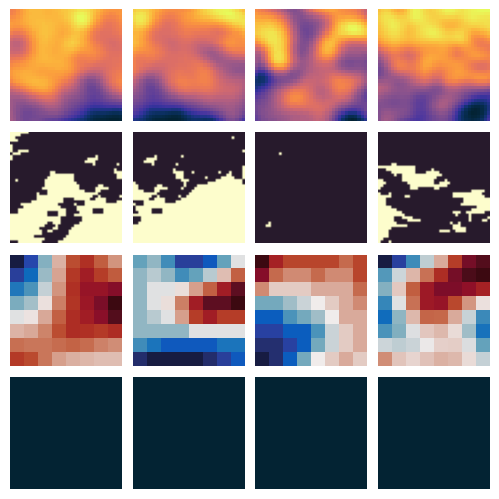

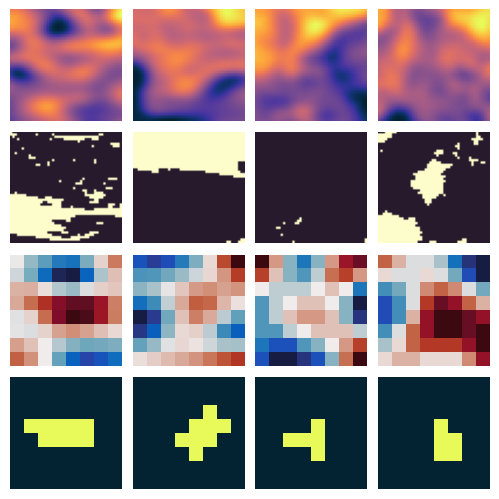

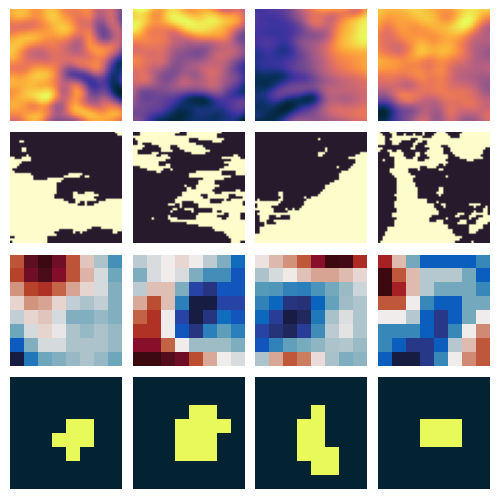

In [7]:
visualize_images_with(0, save_as="images_with_no_cyclone.png") # No eddy
visualize_images_with(1, save_as="images_with_cyclone.png") # Eddy
visualize_images_with(2, save_as="images_with_anticyclone.png") # Reverse eddy

# Visualize on map

In [49]:
min(map(lambda v: min(np.concatenate(v)), df_train["SST_LATITUDE"].values.flatten()))

np.float32(21.025)

In [54]:
# Print min/max lat/lon, used to center image
min_lat = np.round(min(map(lambda v: min(np.concatenate(v)), df_train["SST_LATITUDE"].values.flatten())))
max_lat = np.round(max(map(lambda v: max(np.concatenate(v)), df_train["SST_LATITUDE"].values.flatten())))
min_lon = np.round(min(map(lambda v: min(np.concatenate(v)), df_train["SST_LONGITUDE"].values.flatten())))
max_lon = np.round(max(map(lambda v: max(np.concatenate(v)), df_train["SST_LONGITUDE"].values.flatten())))

print(f"Min lat: {min_lat}\nMax lat: {max_lat}\nMin lon: {min_lon}\nMax lon: {max_lon}\n")

Min lat: 21.0
Max lat: 59.0
Min lon: 286.0
Max lon: 339.0



In [ ]:
def images_on_map(data, categories: list[str], cm="viridis", alpha: list[float]=[0.8], mark_eddy_contour=False, mark_eddy_centre=False, amount_of_days=-1, save_as: str = None):
    plt.figure(figsize=(20, 10), )
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_global()
    ax.coastlines()

    for d, (_, row) in enumerate(data.iterrows()):
        if (amount_of_days >= 0 and d >= amount_of_days):
            break

        # Images
        for j, category in enumerate(categories):
            images = [image for image in row[category]]
            lats = [lat for lat in row[f"{category}_LATITUDE"]]
            lons = [lon for lon in row[f"{category}_LONGITUDE"]]

            for i in range(0, len(images)):
                lon2d, lat2d = np.meshgrid(lons[i], lats[i])
                ax.pcolormesh(
                    lon2d,
                    lat2d,
                    images[i],
                    transform=ccrs.PlateCarree(),
                    cmap=cm,
                    snap=True,
                    alpha=alpha[j],
                    shading="auto",
                )
    
                #if (i > 10): break # TODO: TEMPORARY

        # Mark eddy contour
        if (mark_eddy_contour):
            lats = [lat for lat in row["EDDY_LATITUDE"] if (np.isnan(lat)).any() == False]
            lons = [lat for lat in row["EDDY_LONGITUDE"] if (np.isnan(lat)).any() == False]

            ax.scatter(lons, lats, color=(1, 0, 0, 0.05), s=1, transform=ccrs.PlateCarree(), zorder=5)

        # Mark eddy centre
        if (mark_eddy_centre):
            positions = [pos for pos in row["EDDY_CENTRE"] if (np.isnan(pos)).any() == False]
            lons = list(map(lambda v: v[0], positions))
            lats = list(map(lambda v: v[1], positions))

            ax.scatter(lons, lats, color=(1, 0, 0, 0.5), s=1.0, transform=ccrs.PlateCarree(), zorder=5)

    zoom = 3
    ax.set_extent([
        286 - zoom, 339 + zoom,
        21 - zoom, 59 + zoom
    ], crs=ccrs.PlateCarree())

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

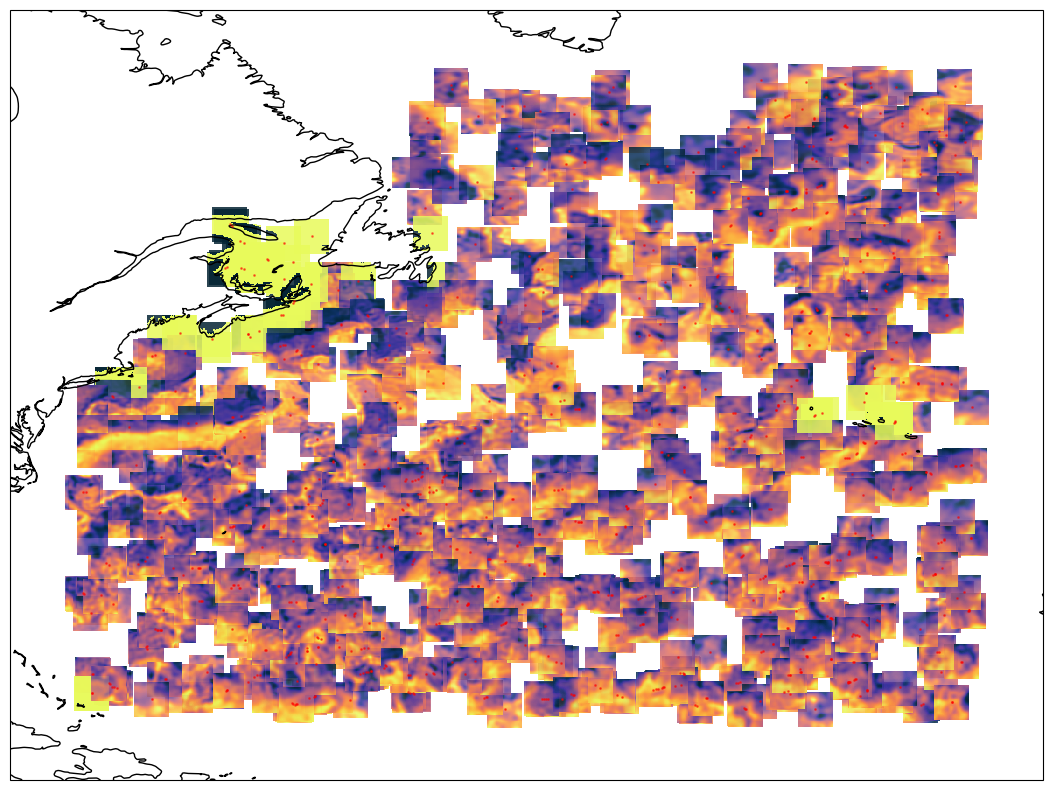

In [68]:
images_on_map(df_train, ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, amount_of_days=10, save_as="sst_map_train.png")

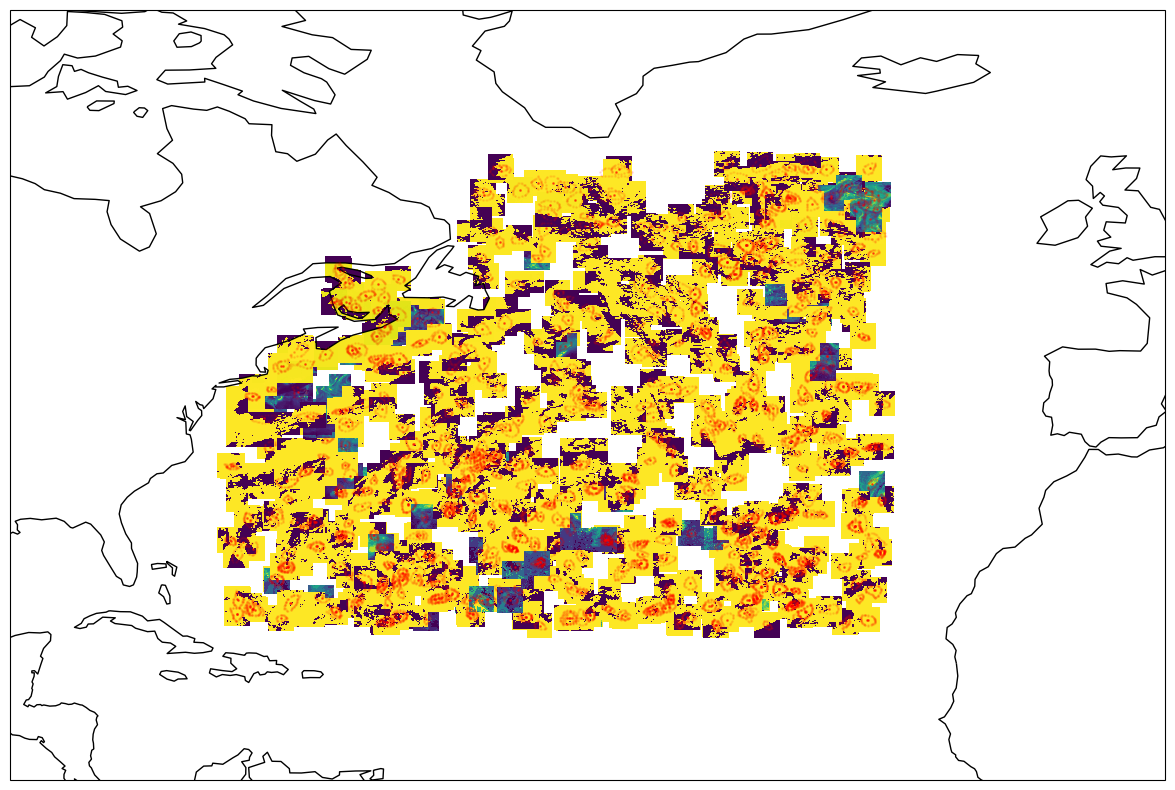

In [10]:

images_on_map(df_train, ["CHLA"], alpha=[1.0], mark_eddy_centre=True, mark_eddy_contour=True, amount_of_days=10)
#images_on_map(df_train, ["SST", "CHLA"], cm=cmocean.cm.thermal, alpha=[1.0, 0.2], mark_eddy_contour=True, mark_eddy_centre=True, amount_of_days=-1)

TypeError: 'float' object is not subscriptable

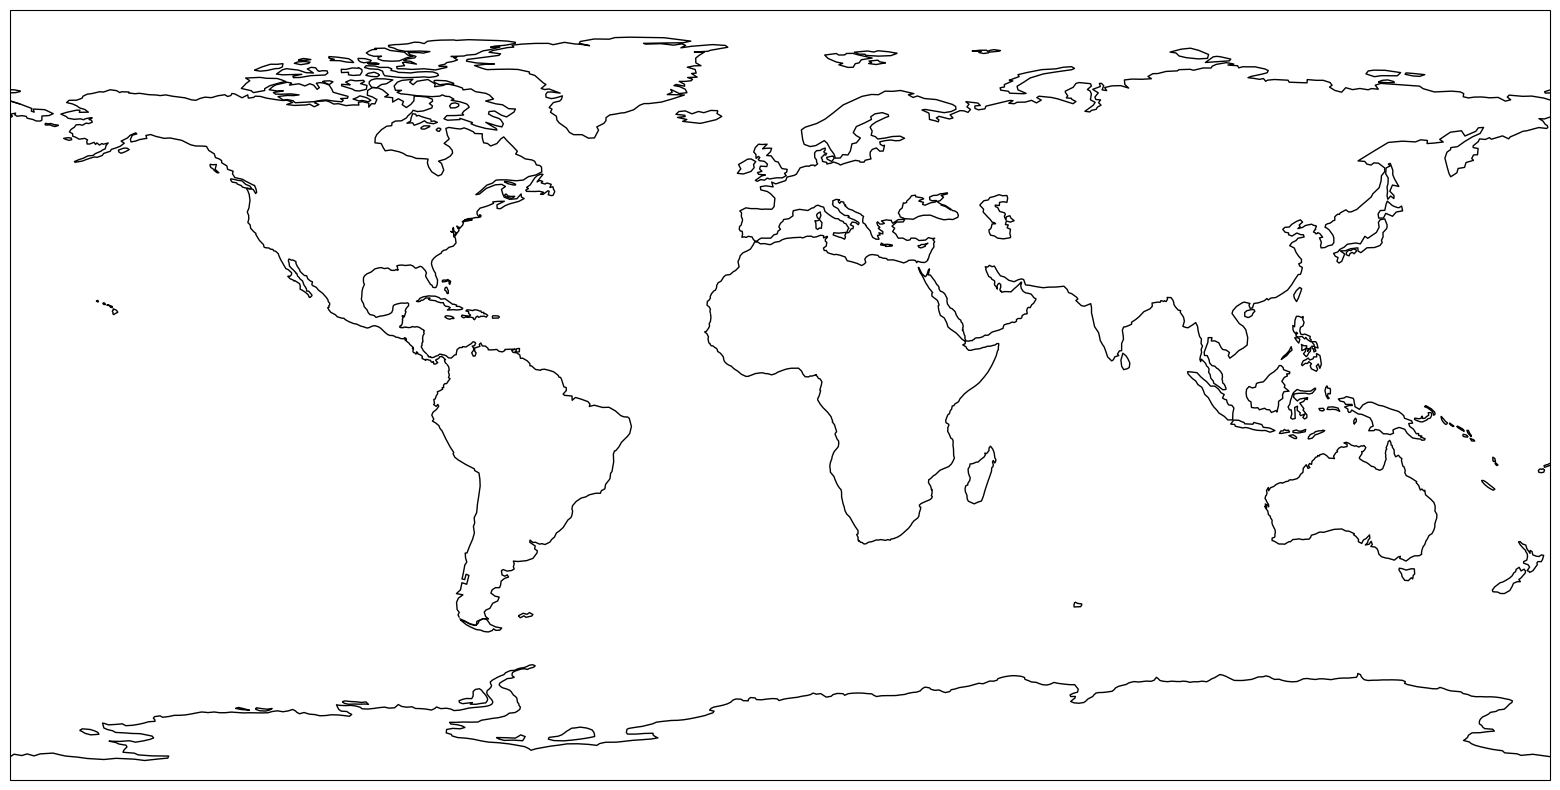

In [11]:
images_on_map(df_train, ["SST", "CHLA"], cm=cmocean.cm.thermal, alpha=0.5, mark_eddy_centre=True)

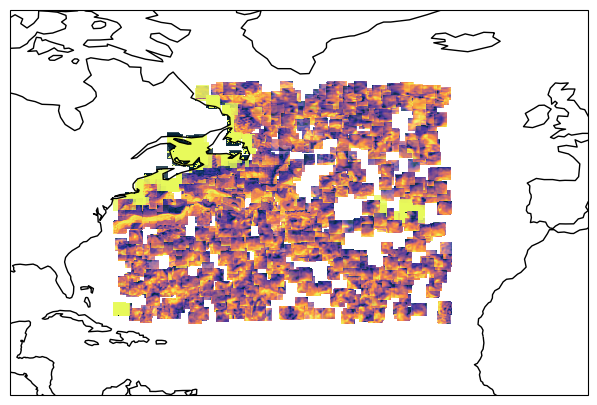

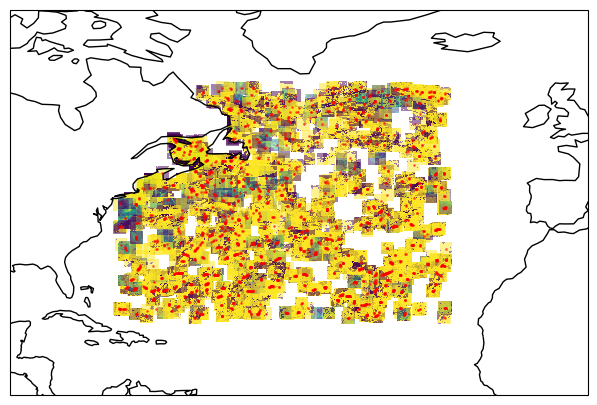

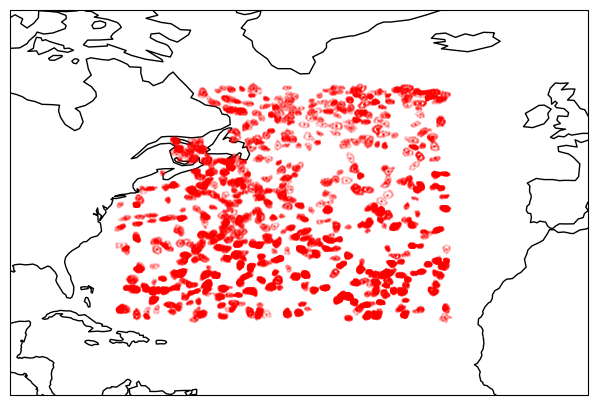

In [ ]:
images_on_map(df_test, ["SST"], cm=cmocean.cm.thermal, alpha=0.8, mark_eddy_centre=False)
images_on_map(df_test, ["CHLA"], alpha=0.5, mark_eddy_centre=True)
images_on_map(df_test, [], mark_eddy_contour=True, mark_eddy_centre=True)

<h1>Other</h1>    

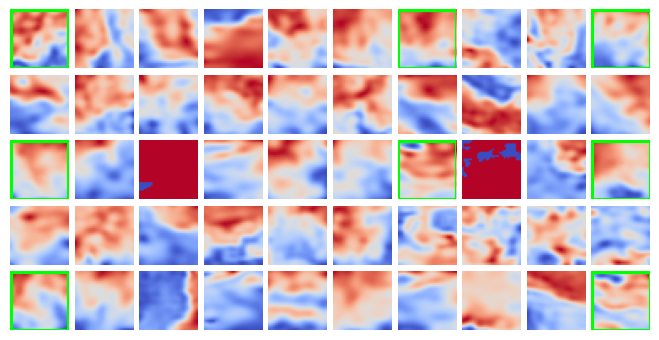

In [ ]:
fig, axs = plt.subplots(5, 10)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.1, hspace=-.7)

random_i = [random.randint(0, len(df_train) - 1) for _ in range(0, 5)]
random_j = [random.randint(0, 50) for _ in range(0, 10)]

for i, axi in enumerate(axs):
    for j, axj in enumerate(axi):
        # Select image
        image = df_train.iloc[random_i[i]]["SST"][random_j[j]]

        # Border?
        if df_train.iloc[random_i[i]]["LABELS"][random_j[j]] == 1:
            rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="lime", lw=3)
            axj.add_patch(rect)
        elif df_train.iloc[random_i[i]]["LABELS"][random_j[j]] == 2:
            rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="blue", lw=3)
            axj.add_patch(rect)
        
        # Image
        axj.imshow(image, cmap="coolwarm")
        axj.axis('off')
        
        # # Text
        # if i == 0: axj.set_title(f"Nr. {j + 1}", fontsize=10)
        # if j == 0: axj.text(-0.2, 0.5, df_train.iloc[i + i_offset].name.strftime("%d.%m.%Y"), transform=axj.transAxes, va='center', ha='right')

# Select train and test

In [ ]:
X_train = df_train[["SST", "CHLA"]]
y_train = df_train[["LABELS"]]

X_test = df_test[["SST", "CHLA"]]
y_test = df_test[["LABELS"]]

# Transformers

In [ ]:
# Transformer: resize images

def _crop(img, bounding): # https://stackoverflow.com/a/50322574
    start = tuple(map(lambda a, da: a//2-da//2, img.shape, bounding))
    end = tuple(map(operator.add, start, bounding))
    slices = tuple(map(slice, start, end))

    return img[slices]

def _resize(data):
    data_c = data.copy()

    min_size = min(min(list(map(lambda v0: list(v0), [map(lambda v1: set(map(lambda v2: v2.shape, v1)), X_train[column]) for column in X_train.columns]))[0])) # wtf
    for category in data_c.columns:
        data_c[category] = data_c[category].map(lambda row: list(map(lambda image: _crop(image, min_size), row)))

    return data_c

t_resize = FunctionTransformer(func=_resize)

In [ ]:
# Transformer: scale images

def _scale_image(img, scaler=MinMaxScaler()):
    shape = img.shape
    scaled = scaler.fit_transform(img.reshape(-1, 1))

    return scaled.reshape(shape)
    

def _scale(data):
    data_c = data.copy()

    for category in data_c.columns:
        data_c[category] = data_c[category].map(lambda row: list(map(lambda image: _scale_image(image, MinMaxScaler()), row)))

    return data_c

t_scale = FunctionTransformer(func=_scale)

In [ ]:
# Transformer: into tensors

# Shape = (Sample, Channel, Width, Height)
def _add_tensors_x(data):
    data_c = data.copy()

    stacks = []
    for column in data_c.columns:
        stacks.append(np.array(data_c[column].explode(column).tolist()))
    data_c = torch.stack(list(map(lambda stack: torch.from_numpy(stack).float(), stacks)))
    data_c = data_c.permute(1, 0, 2, 3)
    
    return data_c

t_tensors_x = FunctionTransformer(func=_add_tensors_x)

In [ ]:
# Assumes LABEL
def _add_tensors_y(data):
    data_c = data.copy()

    flattened = np.concatenate([arr for arr in data_c["LABELS"]])
    data_c = torch.tensor(flattened, dtype=torch.long)

    return data_c

t_tensors_y = FunctionTransformer(func=_add_tensors_y)

# Convolution neural network

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Input to hidden layer
        self.i2h = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 1st (convolution) hidden layer
        self.h1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 2nd (convolution) hidden layer
        self.h2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 3rd (fully connected) hidden layer
        self.h3 = nn.Sequential(
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # 4th (fully connected) hidden layer
        self.h4 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # Hidden layer to output
        self.h2o = nn.Linear(128, 3)

    def forward(self, x):
        out = self.i2h(x)
        #print(f"i2h: {out.shape}")
        out = self.h1(out)
        #print(f"h1: {out.shape}")
        out = self.h2(out)
        #print(f"h2: {out.shape}")
        out = out.view(out.shape[0], -1)
        #print(f"After view {out.shape}")
        out = self.h3(out)
        #print(f"h3: {out.shape}")
        out = self.h4(out)
        #print(f"h4: {out.shape}")
        out = self.h2o(out)
        #print(f"h2o: {out.shape}")

        return out


<h1>Pipeline</h1>

In [ ]:
pipeline = Pipeline([
    ("resize", t_resize.set_output(transform="pandas")),
    ("scale", t_scale.set_output(transform="pandas")),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(),
        criterion=nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        lr=0.01,
        max_epochs=50,
        iterator_train__shuffle=True,
        verbose=10
    )),
])

<h1>Train</h1>

In [ ]:
pipeline.fit(X_train, t_tensors_y.transform(y_train))

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.2561       0.3271        1.0989  5.5231
      2        1.0957       0.3818        1.0925  5.1760
      3        1.0934       0.3818        1.0924  4.9717
      4        1.0934       0.3818        1.0924  4.9751
      5        1.0933       0.3818        1.0926  5.0364
      6        1.0935       0.3818        1.0925  4.9435
      7        1.0928       0.3818        1.0924  5.0975
      8        1.0927       0.3818        1.0924  5.2592
      9        1.0929       0.3818        1.0924  4.9851
     10        1.0930       0.3818        1.0924  5.0942
     11        1.0926       0.3818        1.0924  5.2255
     12        1.0927       0.3818        1.0924  4.9358
     13        1.0930       0.3818        1.0925  4.7575
     14        1.0927       0.3818        1.0924  4.8084
     15        1.0927       0.3818        1.0924  5.1234
     16        1.0926       0.3

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('resize', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function _re...x7d406f5dfcc0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

# Visualize loss

In [ ]:
def visualize_loss(pipeline):
    df_loss = pd.DataFrame(
        list(map(lambda v: [v["epoch"], v["train_loss"], v["valid_loss"]], pipeline.steps[-1][1].history[0:-2]))
    ).rename(columns={ 0: "Epoch", 1: "Training loss", 2: "Validation loss"})

    plt.subplots(figsize=(10, 5))
    plt.plot(df_loss["Epoch"], df_loss["Training loss"], c=RED, label="Training loss")
    plt.plot(df_loss["Epoch"], df_loss["Validation loss"], c=BLUE, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs. validation loss")
    plt.legend()
    plt.grid()
    plt.show()

visualize_loss(pipeline)

NameError: name 'pipeline' is not defined

# Visualize predictions

# Metrics

In [ ]:
class Metrics:
    def __init__(self, model, X, y, cross_validated=True):
        self.cross_validated = cross_validated
        self.measurements = [
            ["Mean Absolute Percentage Error", "neg_mean_absolute_percentage_error", mean_absolute_percentage_error],
            ["Median Absolute Error", "neg_median_absolute_error", median_absolute_error],
            ["R2", "r2", r2_score],
        ]

        if (self.cross_validated):
            self._metrics = list(map(lambda kv: (
                kv[0],
                np.mean(cross_val_score(model, X, y, scoring=kv[1]
            ))), self.measurements))
        else:
            self._metrics = list(map(lambda kv: (
                kv[0],
                kv[2](y, model.predict(X))
            ), self.measurements))

    def __repr__(self):
        if self.cross_validated: return '\n'.join(map(lambda kv: f"{kv[0]} (CV): {np.abs(kv[1]):.5f}", self._metrics))
        else: return '\n'.join(map(lambda kv: f"{kv[0]}: {np.abs(kv[1]):.5f}", self._metrics))

array([0, 0, 0, ..., 0, 0, 0], shape=(4842,))

<h1>Conclusion</h1>

<p>
...
</p>

<h1>References</h1>

<p>[1] Authors. Title. Name. (Year). <a href="https://www.example.com" target="_blank">https://www.example.com/</a> (Accessed online: date)</p>

<p>[1] Dennis G Wilson, Mercator Hackathon, Simon van Gennip, and svangennip. Ocean Eddy Identification. Kaggle. (2022). <a href="https://www.kaggle.com/competitions/mercatorocean" target="_blank">https://www.kaggle.com/competitions/mercatorocean/data</a> (Accessed online: 20.04.2026)</p>